# Match Results Predictor

> In this Jupiter Notebook, I will used Advanced AI models in order to predict football match results.


### 1 Data Loading and Preparation

The raw data comes from [football-data.co.uk](https://football-data.co.uk), which provides free CSV files for every Premier League season since 1993. Each file contains match results, statistics (shots, corners, cards), and betting odds.

**Key decisions made here:**
- We load all 26 seasons (2000–2026) and combine them into one dataset
- Multiple encodings are tried per file since older CSVs use different formats (latin-1, windows-1252)
- We keep only the columns relevant to our model, result, match stats, and odds
- Future fixtures (no result yet) are dropped automatically
- Columns with 90% missing values (Attendance, HHW, AHW etc.) are flagged here and will be dropped in the feature engineering step

In [4]:
import pandas as pd
import glob
import os

# Columns to keep

KEEP_COLS = ["Div", "Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR", "HTHG", "HTAG", "HTR", "Attendance", "Referee", "HS", "AS", "HST", "AST", "HHW", "AHW", "HC", "AC", "HF", "AF", "HO", "AO", "HY", "AY", "HR", "AR", "HBP", "ABP"]

# Load and combine all CSVs 

CSV_DIR = "../Data/Premier League"

all_files = sorted(glob.glob(os.path.join(CSV_DIR, "*.csv")))
print(f"Found {len(all_files)} CSV files")

dfs = []
for path in all_files:
    season = os.path.basename(path).replace(".csv", "")
    for encoding in ["utf-8-sig", "latin-1", "windows-1252"]:
        try:
            df = pd.read_csv(
                path,
                encoding=encoding,
                on_bad_lines="skip",
                engine="python",
            )
            break
        except UnicodeDecodeError:
            continue
    df["Season"] = season
    dfs.append(df)

print(f"\nLoaded {len(dfs)} files successfully")

raw = pd.concat(dfs, ignore_index=True)
print(f"Total rows: {len(raw)}")

# Keep only relevant columns, filling missing ones with NaN

data = raw.reindex(columns=KEEP_COLS + ["Season"])

# Basic cleanup

def parse_date(val):
    for fmt in ["%d/%m/%Y", "%d/%m/%y"]:
        try:
            return pd.to_datetime(val, format=fmt)
        except:
            pass
    return pd.NaT

data["Date"] = data["Date"].apply(parse_date)

data = data.dropna(subset=["FTR"])

data = data.sort_values("Date").reset_index(drop=True)

# Summary

print(f"\nMissing values per column:")
missing = data.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    print("  None!")
else:
    for col, count in missing.items():
        pct = count / len(data) * 100
        print(f"  {col:<10} {count:>5} missing  ({pct:.1f}%)")

Found 26 CSV files

Loaded 26 files successfully
Total rows: 9720

Missing values per column:
  Attendance  8960 missing  (92.2%)
  HHW         8959 missing  (92.2%)
  AHW         8959 missing  (92.2%)
  HO          8959 missing  (92.2%)
  AO          8959 missing  (92.2%)
  HBP         8959 missing  (92.2%)
  ABP         8959 missing  (92.2%)


### 2 Adding Gx Columns

The meaning of xG in football is “expected goals.” It’s a statistic used to measure how likely a shot is to become a goal.

Each shot gets a value between 0 and 1 based on factors like:
- Distance from goal
- Angle
- Whether it was a header or a shot with the foot
- Whether it was a counterattack
- How many defenders were nearby
- The type of pass before the shot

In [5]:
import asyncio
import aiohttp
import understat
import pandas as pd
from tqdm import tqdm

# Fetch xG data from Understat
# Understat covers Premier League from 2014/15 onwards
# Seasons before that will have NaN for xG columns

SEASONS = list(range(2014, 2026))

async def fetch_season(session, year):
    u = understat.Understat(session)
    matches = await u.get_league_results("EPL", year)
    rows = []
    for m in matches:
        rows.append({
            "Date"     : m["datetime"][:10],
            "HomeTeam" : m["h"]["title"],
            "AwayTeam" : m["a"]["title"],
            "xG_home"  : float(m["xG"]["h"]),
            "xG_away"  : float(m["xG"]["a"]),
        })
    return rows

async def fetch_all():
    all_rows = []
    async with aiohttp.ClientSession() as session:
        for year in tqdm(SEASONS, desc="Fetching xG"):
            try:
                rows = await fetch_season(session, year)
                all_rows.extend(rows)
                print(f"  {year}/{str(year+1)[-2:]}  →  {len(rows)} matches")
            except Exception as e:
                print(f"  {year}  →  FAILED: {e}")
    return all_rows

# Running the async fetcher (works in Jupyter with nest_asyncio)
import nest_asyncio
nest_asyncio.apply()

rows = asyncio.run(fetch_all())
xg_df = pd.DataFrame(rows)
xg_df["Date"] = pd.to_datetime(xg_df["Date"])

print(f"\nFetched {len(xg_df)} xG records")

# Normalise team names to match football-data.co.uk because understat uses different team names

NAME_MAP = {
    "Manchester United"  : "Man United",
    "Manchester City"    : "Man City",
    "Newcastle United"   : "Newcastle",
    "Tottenham"          : "Tottenham",
    "Wolverhampton"      : "Wolves",
    "Sheffield United"   : "Sheffield United",
    "West Bromwich"      : "West Brom",
    "Nottingham Forest"  : "Nott'm Forest",
    "Leeds"              : "Leeds",
    "Leicester"          : "Leicester",
}

xg_df["HomeTeam"] = xg_df["HomeTeam"].replace(NAME_MAP)
xg_df["AwayTeam"] = xg_df["AwayTeam"].replace(NAME_MAP)

# Merge into main dataset

data = pd.merge(
    data,
    xg_df,
    on=["Date", "HomeTeam", "AwayTeam"],
    how="left",   # keep all rows, NaN for seasons before 2014/15
)

# Summary

total     = len(data)
with_xg   = data["xG_home"].notna().sum()
without   = total - with_xg

print(f"\n{'─'*45}")
print(f"Total matches : {total:,}")
print(f"With xG       : {with_xg:,}  ({with_xg/total*100:.1f}%)")
print(f"Without xG    : {without:,}")

data[["Date", "HomeTeam", "AwayTeam", "FTR", "xG_home", "xG_away"]].tail(10)
data.to_csv("../Data/combined_data.csv", index=False)

Fetching xG:  17%|█▋        | 2/12 [00:01<00:05,  1.94it/s]

  2014/15  →  380 matches
  2015/16  →  380 matches


Fetching xG:  33%|███▎      | 4/12 [00:01<00:01,  4.02it/s]

  2016/17  →  380 matches
  2017/18  →  380 matches


Fetching xG:  50%|█████     | 6/12 [00:01<00:01,  5.86it/s]

...

  2020/21  →  380 matches
  2021/22  →  380 matches


Fetching xG:  83%|████████▎ | 10/12 [00:02<00:00,  7.78it/s]

  2022/23  →  380 matches
  2023/24  →  380 matches


Fetching xG: 100%|██████████| 12/12 [00:02<00:00,  5.26it/s]

  2024/25  →  380 matches
  2025/26  →  353 matches

Fetched 4533 xG records

─────────────────────────────────────────────
Total matches : 9,719
With xG       : 3,945  (40.6%)
Without xG    : 5,774


### Midway Data Analysis 

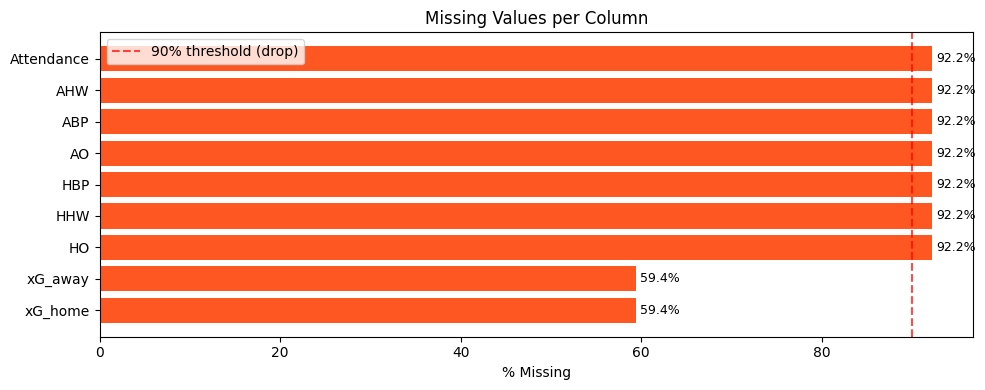

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

# Read raw combined data to show original missing values
raw_check = pd.read_csv("../Data/combined_data.csv")

missing = raw_check.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(missing.index, missing.values / len(raw_check) * 100, color="#FF5722")
ax.axvline(x=90, color="red", linestyle="--", alpha=0.7, label="90% threshold (drop)")
ax.set_xlabel("% Missing")
ax.set_title("Missing Values per Column")
ax.legend()
for bar, val in zip(bars, missing.values / len(raw_check) * 100):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../Data/missing_values.png", dpi=150, bbox_inches="tight")
plt.show()

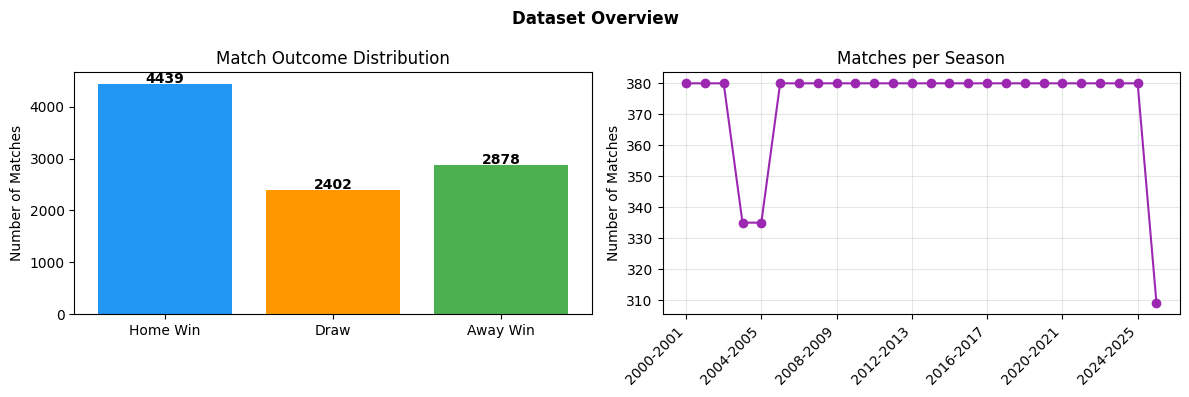

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# Read from CSV so we have FTR and Season columns still available
raw_check = pd.read_csv("../Data/combined_data.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Dataset Overview", fontweight="bold")

# Match outcomes
outcome_counts = raw_check["FTR"].value_counts()
ax1.bar(["Home Win", "Draw", "Away Win"],
        [outcome_counts.get("H", 0), outcome_counts.get("D", 0), outcome_counts.get("A", 0)],
        color=["#2196F3", "#FF9800", "#4CAF50"])
ax1.set_title("Match Outcome Distribution")
ax1.set_ylabel("Number of Matches")
for i, v in enumerate([outcome_counts.get("H",0), outcome_counts.get("D",0), outcome_counts.get("A",0)]):
    ax1.text(i, v + 20, str(v), ha="center", fontweight="bold")

# Matches per season
season_counts = raw_check.groupby("Season").size()
ax2.plot(range(len(season_counts)), season_counts.values, marker="o", color="#9C27B0")
ax2.set_xticks(range(0, len(season_counts), 4))
ax2.set_xticklabels(list(season_counts.index)[::4], rotation=45, ha="right")
ax2.set_title("Matches per Season")
ax2.set_ylabel("Number of Matches")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../Data/dataset_overview.png", dpi=150, bbox_inches="tight")
plt.show()

### 3 Sentiment Analysis using NLP

Football match outcomes are influenced by factors that don't appear in statistics like key injuries, suspensions, poor team morale, or exceptional recent form. To capture this, we use a two-step NLP pipeline:

**Step 1 — News fetching (Guardian API)**
For each match from 2020 onwards, we query The Guardian's football section for articles about each team published in the 5 days before the match. The Guardian provides a free developer API with 500 requests/day.

**Step 2 — Sentiment scoring (HuggingFace)**
Each article is passed through `cardiffnlp/twitter-roberta-base-sentiment`, a RoBERTa model fine-tuned on social media text. It classifies text as:
- `LABEL_0` = Negative (like injury news, poor form)
- `LABEL_1` = Neutral
- `LABEL_2` = Positive (like winning streak, player returns)

The scores are averaged into a single value between **-1.0 (very negative) and +1.0 (very positive)** per team per match. This value becomes a feature in the neural network, making the LLM a meaningful contributor to predictions.

Note: Due to the 500 requests/day API limit, sentiment data is collected incrementally over multiple days. Matches without sentiment data yet default to 0 (neutral).

In [6]:
from transformers import pipeline

print("Loading sentiment model...")
sentiment_model = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment",
    truncation=True,
    max_length=512
)
print("Model loaded!")

c:\Users\angel\Files\UCLL\Semester 4\Advanced AI\Match Results Project\VSC - Project\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading sentiment model...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 20105.29it/s]


Model loaded!


In [ ]:
import requests
import pandas as pd
import time
import os
from datetime import timedelta

GUARDIAN_API_KEY = os.getenv("GUARDIAN_API_KEY")

data["Date"] = pd.to_datetime(data["Date"])
recent = data[data["Date"].dt.year >= 2020].copy().reset_index(drop=True)

# Load checkpoint if exists (so you can resume if interrupted)
import os
CHECKPOINT = "../Data/sentiment_checkpoint.csv"
if os.path.exists(CHECKPOINT):
    checkpoint_df = pd.read_csv(CHECKPOINT)
    checkpoint_df["Date"] = pd.to_datetime(checkpoint_df["Date"])
    done_indices = set(checkpoint_df.index)
    print(f"Resuming from checkpoint — {len(done_indices)} already done")
else:
    checkpoint_df = recent.copy()
    checkpoint_df["home_sentiment"] = None
    checkpoint_df["away_sentiment"] = None
    done_indices = set()
    print("Starting fresh")

# Fetch headlines from Guardian API

def fetch_guardian_headlines(team, match_date, days_before=5):
    date_from = (match_date - timedelta(days=days_before)).strftime("%Y-%m-%d")
    date_to   = match_date.strftime("%Y-%m-%d")
    try:
        r = requests.get(
            "https://content.guardianapis.com/search",
            params={
                "q"           : f"{team} football",
                "section"     : "football",
                "from-date"   : date_from,
                "to-date"     : date_to,
                "page-size"   : 5,
                "order-by"    : "relevance",
                "show-fields" : "headline,trailText",
                "api-key"     : GUARDIAN_API_KEY,
            },
            timeout=10
        )
        results = r.json().get("response", {}).get("results", [])
        texts = []
        for a in results:
            fields = a.get("fields", {})
            headline = fields.get("headline", a.get("webTitle", ""))
            trail    = fields.get("trailText", "")
            texts.append(f"{headline}. {trail}".strip())
        return texts if texts else None
    except Exception:
        return None

# Score sentiment with HuggingFace model

LABEL_SCORE = {"LABEL_0": -1.0, "LABEL_1": 0.0, "LABEL_2": 1.0}

def score_headlines(texts):
    if not texts:
        return None
    try:
        results = sentiment_model(texts)
        scores  = [LABEL_SCORE[r["label"]] * r["score"] for r in results]
        return round(sum(scores) / len(scores), 4)
    except Exception:
        return None

# Process all matches

for i, row in checkpoint_df.iterrows():
    if pd.notna(checkpoint_df.at[i, "home_sentiment"]):
        continue  # already processed, skip

    home_texts = fetch_guardian_headlines(row["HomeTeam"], row["Date"])
    away_texts = fetch_guardian_headlines(row["AwayTeam"], row["Date"])

    checkpoint_df.at[i, "home_sentiment"] = score_headlines(home_texts)
    checkpoint_df.at[i, "away_sentiment"] = score_headlines(away_texts)

    # Save checkpoint every 50 matches
    if i % 50 == 0:
        checkpoint_df.to_csv(CHECKPOINT, index=False)
        done = i + 1
        h = checkpoint_df.at[i, "home_sentiment"]
        print(f"  {done}/{len(recent)}  {row['HomeTeam']} vs {row['AwayTeam']}  → home: {h}")

    time.sleep(0.5)

# Final save & merge

checkpoint_df.to_csv(CHECKPOINT, index=False)

data = data.merge(
    checkpoint_df[["Date", "HomeTeam", "AwayTeam", "home_sentiment", "away_sentiment"]],
    on=["Date", "HomeTeam", "AwayTeam"],
    how="left"
)

# Summary

total     = len(data)
with_sent = data["home_sentiment"].notna().sum()
print(f"\n{'─'*45}")
print(f"Total matches     : {total:,}")
print(f"With sentiment    : {with_sent:,}  ({with_sent/total*100:.1f}%)")
print(f"\nSample scores:")
print(data[data["home_sentiment"].notna()][
    ["Date","HomeTeam","AwayTeam","home_sentiment","away_sentiment"]
].head(10).to_string())

data.to_csv("../Data/combined_data.csv", index=False)
if os.path.exists(CHECKPOINT):
    os.remove(CHECKPOINT)
print("Done!")

Resuming from checkpoint — 2390 already done
  1501/2390  Bournemouth vs Fulham  → home: nan


KeyboardInterrupt: 

In [ ]:
import requests
import os

GUARDIAN_API_KEY = os.getenv("GUARDIAN_API_KEY")

r = requests.get(
    "https://content.guardianapis.com/search",
    params={
        "q"       : "Arsenal football",
        "section" : "football",
        "page-size": 1,
        "api-key" : GUARDIAN_API_KEY,
    }
)

response = r.json().get("response", {})
status   = response.get("status")
pages    = response.get("pages")

if status == "ok":
    print("API is working — quota refreshed, good to go!")
    print(f"   Test query returned {pages} pages of results")
else:
    print("API not working yet")
    print(f"   Response: {r.json()}")

API not working yet
   Response: {'message': 'API rate limit exceeded'}


### 4 Feature Engineering

Raw match statistics can't be fed directly into the model, they describe what happened *during* the match, which we wouldn't know beforehand. Instead, we engineer **pre-match features** that represent each team's form and quality going into the game.

**Features engineered (rolling over last 5 matches):**
| Feature | Description |
|---|---|
| `home_form` / `away_form` | Average points per game (W=3, D=1, L=0) |
| `home_gf_avg` / `away_gf_avg` | Average goals scored |
| `home_ga_avg` / `away_ga_avg` | Average goals conceded |
| `home_xg_avg` / `away_xg_avg` | Average expected goals (quality of chances) |
| `h2h_home_winrate` | Home team win rate in last 5 meetings vs this opponent |
| `home_sentiment` / `away_sentiment` | Pre-match news sentiment score (-1.0 to +1.0) |

Data leakage prevention: All rolling statistics use only historical data, only matches played before the current one are included. This is critical to avoid the model "seeing the future" during training.

In [ ]:
import pandas as pd
import numpy as np

data = pd.read_csv("../Data/combined_data.csv")
print(f"Loaded {len(data)} rows, columns: {list(data.columns)}")

# Step 1: Filter to 2014 onwards (where xG exists)

data["Date"] = pd.to_datetime(data["Date"])
data = data[data["Date"].dt.year >= 2014].copy().reset_index(drop=True)
print(f"Matches from 2014 onwards: {len(data)}")

# Step 2: Drop useless columns

DROP_COLS = [
    "Div", "Season", "Referee", "Attendance",  # irrelevant
    "HHW", "AHW", "HO", "AO", "HBP", "ABP",    # 90% missing
    "HTHG", "HTAG", "HTR",                     # half time, not available pre match
    "HS", "AS", "HST", "AST",                  # post match stats, not available pre match
    "HC", "AC", "HF", "AF",                    # post match stats
    "HY", "AY", "HR", "AR",                    # post match stats
]
data = data.drop(columns=[c for c in DROP_COLS if c in data.columns])
print(f"Columns remaining: {list(data.columns)}")

# Step 3: Encode target variable

data["target"] = data["FTR"].map({"H": 0, "D": 1, "A": 2})
data = data.drop(columns=["FTR"])

# Step 4: Feature Engineering
# CRITICAL: only use data available BEFORE the match (no leakage)
# We calculate rolling stats over the last 5 games for each team

data = data.sort_values("Date").reset_index(drop=True)

def rolling_team_stats(df, team_col, goals_for_col, goals_against_col, xg_col, result_col, prefix, n=5):
    """Calculate rolling averages for a team over last N matches."""
    results = []
    for idx, row in df.iterrows():
        team       = row[team_col]
        match_date = row["Date"]

        # Get all previous matches for this team (home or away)
        home_mask = (df["HomeTeam"] == team) & (df["Date"] < match_date)
        away_mask = (df["AwayTeam"] == team) & (df["Date"] < match_date)

        home_matches = df[home_mask].tail(n)
        away_matches = df[away_mask].tail(n)

        # Combine and take last N
        all_prev = pd.concat([home_matches, away_matches]).sort_values("Date").tail(n)

        if len(all_prev) == 0:
            results.append({
                f"{prefix}_form"   : np.nan,
                f"{prefix}_gf_avg" : np.nan,
                f"{prefix}_ga_avg" : np.nan,
                f"{prefix}_xg_avg" : np.nan,
            })
            continue

        # Form: points per game (W=3, D=1, L=0)
        def get_points(r, team):
            if r["FTR"] == "H": return 3 if r["HomeTeam"] == team else 0
            if r["FTR"] == "A": return 0 if r["HomeTeam"] == team else 3
            return 1

        prev_with_ftr = df.loc[all_prev.index].copy()
        points = prev_with_ftr.apply(lambda r: get_points(r, team), axis=1)
        form   = points.mean()

        # Goals for/against
        gf = pd.concat([
            df.loc[home_mask, "FTHG"].tail(n),
            df.loc[away_mask, "FTAG"].tail(n)
        ]).mean()

        ga = pd.concat([
            df.loc[home_mask, "FTAG"].tail(n),
            df.loc[away_mask, "FTHG"].tail(n)
        ]).mean()

        # xG average
        xg = pd.concat([
            df.loc[home_mask, "xG_home"].tail(n),
            df.loc[away_mask, "xG_away"].tail(n)
        ]).mean()

        results.append({
            f"{prefix}_form"   : round(form, 4),
            f"{prefix}_gf_avg" : round(gf,   4),
            f"{prefix}_ga_avg" : round(ga,   4),
            f"{prefix}_xg_avg" : round(xg,   4),
        })

    return pd.DataFrame(results, index=df.index)

# We need FTR temporarily for form calculation
data["FTR"] = data["target"].map({0: "H", 1: "D", 2: "A"})

print("Engineering home team features...")
home_features = rolling_team_stats(data, "HomeTeam", "FTHG", "FTAG", "xG_home", "FTR", "home")

print("Engineering away team features...")
away_features = rolling_team_stats(data, "AwayTeam", "FTAG", "FTHG", "xG_away", "FTR", "away")

data = pd.concat([data, home_features, away_features], axis=1)
data = data.drop(columns=["FTR"], errors="ignore")

# Step 5: Add head to head feature

def h2h_form(df, idx, home_team, away_team, n=5):
    """Home team win rate in last N meetings vs this away team."""
    mask = (
        ((df["HomeTeam"] == home_team) & (df["AwayTeam"] == away_team)) |
        ((df["HomeTeam"] == away_team) & (df["AwayTeam"] == home_team))
    ) & (df["Date"] < df.loc[idx, "Date"])
    prev = df[mask].tail(n)
    if len(prev) == 0:
        return np.nan
    wins = sum(
        1 for _, r in prev.iterrows()
        if (r["HomeTeam"] == home_team and r["target"] == 0) or
           (r["AwayTeam"] == home_team and r["target"] == 2)
    )
    return round(wins / len(prev), 4)

print("Engineering head-to-head features...")
data["h2h_home_winrate"] = [
    h2h_form(data, i, row["HomeTeam"], row["AwayTeam"])
    for i, row in data.iterrows()
]

# Step 6: Final cleanup

# Drop FTHG and FTAG now that feature engineering is done
data = data.drop(columns=["FTHG", "FTAG"], errors="ignore")

# Fill sentiment NaN with 0 (neutral) for matches without news data
if "home_sentiment" in data.columns:
    data["home_sentiment"] = data["home_sentiment"].fillna(0)
    data["away_sentiment"] = data["away_sentiment"].fillna(0)

# Drop rows where we have no rolling stats (first few matches of each team)
data = data.dropna(subset=["home_form", "away_form"]).reset_index(drop=True)

# Define feature cols after all drops
feature_cols = [c for c in data.columns if c not in ["Date", "HomeTeam", "AwayTeam", "target"]]

# Fill remaining NaN with column median
for col in feature_cols:
    if data[col].isnull().any():
        data[col] = data[col].fillna(data[col].median())

# Summary

print(f"\nFinal dataset : {len(data)} matches")
print(f"Features      : {feature_cols}")
print(f"\nTarget distribution:")
print(data["target"].value_counts().sort_index().rename({0: "Home Win", 1: "Draw", 2: "Away Win"}))

data.to_csv("../Data/model_data.csv", index=False)
print("\nSaved to model_data.csv!")

Loaded 9719 rows, columns: ['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Attendance', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HHW', 'AHW', 'HC', 'AC', 'HF', 'AF', 'HO', 'AO', 'HY', 'AY', 'HR', 'AR', 'HBP', 'ABP', 'Season', 'xG_home', 'xG_away']
Matches from 2014 onwards: 4679
Columns remaining: ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'xG_home', 'xG_away']
Engineering home team features... (this will take 10-20 mins)
Engineering away team features...
Engineering head-to-head features...

Final dataset : 4654 matches
Features      : ['xG_home', 'xG_away', 'home_form', 'home_gf_avg', 'home_ga_avg', 'home_xg_avg', 'away_form', 'away_gf_avg', 'away_ga_avg', 'away_xg_avg', 'h2h_home_winrate']

Target distribution:
target
Home Win    2077
Draw        1089
Away Win    1488
Name: count, dtype: int64

Saved to model_data.csv!


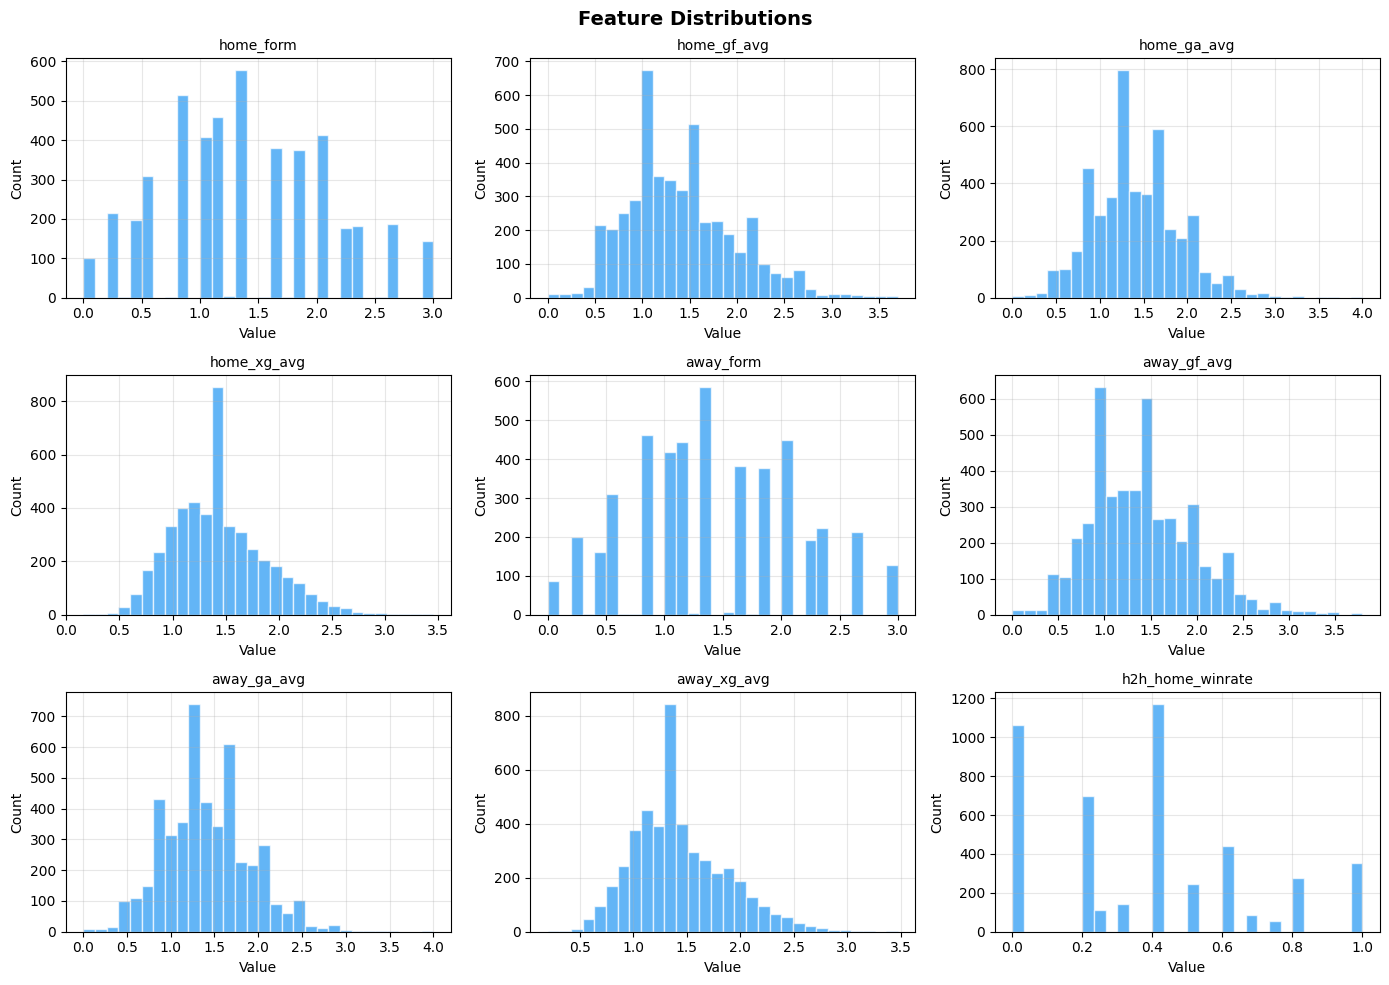

In [26]:
import matplotlib.pyplot as plt

FEATURE_COLS = ["home_form", "home_gf_avg", "home_ga_avg", "home_xg_avg",
                "away_form", "away_gf_avg", "away_ga_avg", "away_xg_avg",
                "h2h_home_winrate"]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle("Feature Distributions", fontsize=14, fontweight="bold")

for ax, col in zip(axes.flatten(), FEATURE_COLS):
    ax.hist(data[col].dropna(), bins=30, color="#2196F3", alpha=0.7, edgecolor="white")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../Data/feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### 5  Neural Network

We use a Multi Layer Perceptron (MLP) built in PyTorch to classify each match into one of three outcomes: Home Win (0), Draw (1), Away Win (2).

**Key design choices:**
- **BatchNorm** stabilises training across the varying scales of our features
- **Dropout (30%)** prevents overfitting on a dataset of arounf 4000 matches
- **Class weights [1.0, 1.5, 1.0]** give draws extra importance since they are underrepresented and harder to predict
- **ReduceLROnPlateau** scheduler halves the learning rate when validation loss plateaus
- Best model weights (lowest validation loss) are saved and restored before evaluation

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd

# Prepare features & target

FEATURE_COLS = [
    "home_form", "home_gf_avg", "home_ga_avg", "home_xg_avg",
    "away_form", "away_gf_avg", "away_ga_avg", "away_xg_avg",
    "h2h_home_winrate",
]
if "home_sentiment" in data.columns:
    FEATURE_COLS += ["home_sentiment", "away_sentiment"]

X = data[FEATURE_COLS].values.astype(np.float32)
y = data["target"].values.astype(np.int64)

# Train/val/test split (70/15/15)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Normalise features

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Convert to PyTorch tensors

def to_loader(X, y, batch_size=64, shuffle=True):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(X_train, y_train, shuffle=True)
val_loader   = to_loader(X_val,   y_val,   shuffle=False)
test_loader  = to_loader(X_test,  y_test,  shuffle=False)

# Define the neural network

class MatchPredictor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 3)   # 3 outputs: Home Win, Draw, Away Win
        )

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model     = MatchPredictor(input_dim=len(FEATURE_COLS)).to(device)

# Give draws more weight so the model learns to predict them
class_weights = torch.tensor([1.0, 1.5, 1.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

# Training loop

EPOCHS     = 100
best_val   = float("inf")
best_state = None
history    = {"train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    # Train
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validate
    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            out      = model(X_batch)
            val_loss += criterion(out, y_batch).item()
            correct  += (out.argmax(1) == y_batch).sum().item()
            total    += y_batch.size(0)
    val_loss /= len(val_loader)
    val_acc   = correct / total

    scheduler.step(val_loss)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_loss < best_val:
        best_val   = val_loss
        best_state = model.state_dict().copy()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS}  train_loss: {train_loss:.4f}  val_loss: {val_loss:.4f}  val_acc: {val_acc:.3f}")

# Evaluate on test set

model.load_state_dict(best_state)
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print("\n── Test Set Results ──────────────────────────────")
print(classification_report(all_labels, all_preds, target_names=["Home Win", "Draw", "Away Win"]))

# Save model & scaler

import pickle
torch.save(best_state, "../Data/model.pth")
with open("../Data/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open("../Data/feature_cols.pkl", "wb") as f:
    pickle.dump(FEATURE_COLS, f)
print("Model saved!")

# Prediction function (give it two team names)

def predict_match(home_team, away_team):

    def get_team_stats(team, is_home):
        home_m = data[data["HomeTeam"] == team].tail(5)
        away_m = data[data["AwayTeam"] == team].tail(5)
        all_m  = pd.concat([home_m, away_m]).sort_values("Date").tail(5)
        prefix = "home" if is_home else "away"
        return {
            f"{prefix}_form"   : all_m[f"{prefix}_form"].mean(),
            f"{prefix}_gf_avg" : all_m[f"{prefix}_gf_avg"].mean(),
            f"{prefix}_ga_avg" : all_m[f"{prefix}_ga_avg"].mean(),
            f"{prefix}_xg_avg" : all_m[f"{prefix}_xg_avg"].mean(),
        }

    def get_h2h(home_team, away_team, n=5):
        """Look up real h2h win rate from dataset instead of hardcoding."""
        mask = (
            ((data["HomeTeam"] == home_team) & (data["AwayTeam"] == away_team)) |
            ((data["HomeTeam"] == away_team) & (data["AwayTeam"] == home_team))
        )
        prev = data[mask].tail(n)
        if len(prev) == 0:
            return 0.4  # fallback to neutral if no history
        wins = sum(
            1 for _, r in prev.iterrows()
            if (r["HomeTeam"] == home_team and r["target"] == 0) or
               (r["AwayTeam"] == home_team and r["target"] == 2)
        )
        return round(wins / len(prev), 4)

    home_stats   = get_team_stats(home_team, is_home=True)
    away_stats   = get_team_stats(away_team, is_home=False)
    h2h_winrate  = get_h2h(home_team, away_team)

    features = {**home_stats, **away_stats, "h2h_home_winrate": h2h_winrate}
    if "home_sentiment" in FEATURE_COLS:
        features["home_sentiment"] = 0.0
        features["away_sentiment"] = 0.0

    X_input = np.array([[features[c] for c in FEATURE_COLS]], dtype=np.float32)
    X_input = scaler.transform(X_input)

    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(torch.tensor(X_input).to(device)), dim=1).cpu().numpy()[0]

    labels = ["Home Win", "Draw", "Away Win"]
    print(f"\n {home_team} vs {away_team}")
    print(f"{'─'*35}")
    for label, prob in zip(labels, probs):
        bar = "█" * int(prob * 30)
        print(f"  {label:<12} {prob*100:5.1f}%  {bar}")
    print(f"\n  H2H win rate   : {h2h_winrate*100:.0f}% in favour of {home_team}")
    print(f"  Prediction     : {labels[probs.argmax()]}")

# Try some matches
predict_match("Arsenal", "Man City")
predict_match("Man City", "Arsenal")
predict_match("Liverpool", "Chelsea")
predict_match("Man United", "Tottenham")
predict_match("Newcastle", "Arsenal")

Using device: cpu
Epoch  10/100  train_loss: 1.0172  val_loss: 1.0151  val_acc: 0.521
Epoch  20/100  train_loss: 1.0102  val_loss: 1.0192  val_acc: 0.496
Epoch  30/100  train_loss: 1.0027  val_loss: 1.0209  val_acc: 0.501
Epoch  40/100  train_loss: 1.0001  val_loss: 1.0208  val_acc: 0.497
Epoch  50/100  train_loss: 1.0032  val_loss: 1.0212  val_acc: 0.499
Epoch  60/100  train_loss: 1.0058  val_loss: 1.0204  val_acc: 0.499
Epoch  70/100  train_loss: 1.0058  val_loss: 1.0214  val_acc: 0.497
Epoch  80/100  train_loss: 1.0113  val_loss: 1.0210  val_acc: 0.496
Epoch  90/100  train_loss: 1.0042  val_loss: 1.0213  val_acc: 0.499
Epoch 100/100  train_loss: 1.0052  val_loss: 1.0223  val_acc: 0.493

── Test Set Results ──────────────────────────────
              precision    recall  f1-score   support

    Home Win       0.56      0.69      0.62       312
        Draw       0.24      0.17      0.20       163
    Away Win       0.50      0.46      0.48       224

    accuracy                    

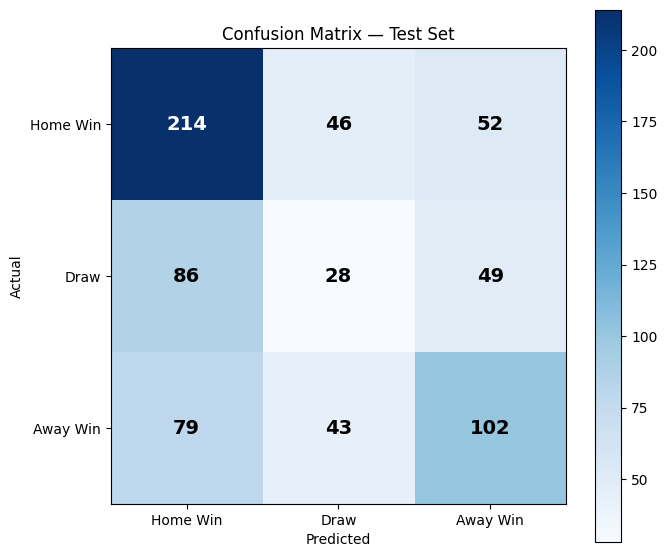

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im)

classes = ["Home Win", "Draw", "Away Win"]
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix, Test Set")

# Add numbers inside cells
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i, j]),
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black",
                fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("../Data/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

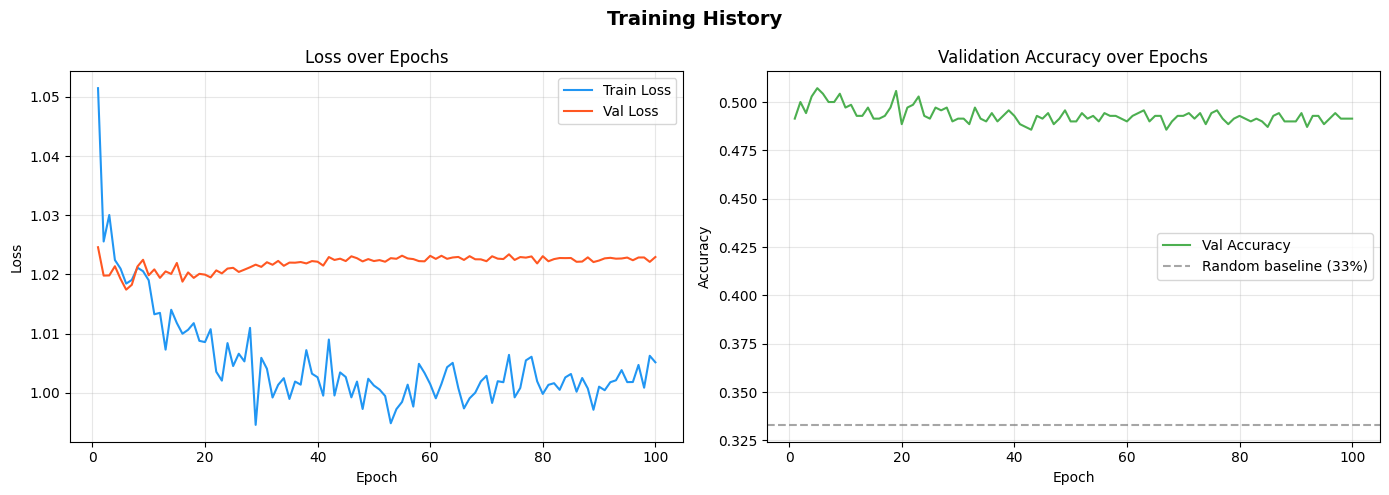

Saved to training_curves.png!


In [17]:
import matplotlib.pyplot as plt

# Training curves

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training History", fontsize=14, fontweight="bold")

epochs = range(1, len(history["train_loss"]) + 1)

# Loss plot
ax1.plot(epochs, history["train_loss"], label="Train Loss", color="#2196F3")
ax1.plot(epochs, history["val_loss"],   label="Val Loss",   color="#FF5722")
ax1.set_title("Loss over Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(epochs, history["val_acc"], label="Val Accuracy", color="#4CAF50")
ax2.axhline(y=0.333, color="gray", linestyle="--", alpha=0.7, label="Random baseline (33%)")
ax2.set_title("Validation Accuracy over Epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../Data/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to training_curves.png!")